# Лабораторна робота №3 “Кластеризація”
## Мета
Ознайомитися з методами кластеризації (clustering) на прикладі реального набору музичних даних Spotify Tracks Dataset. Навчитись підбирати оптимальну кількість кластерів (k) за допомогою методу ліктя (elbow), виконувати кластеризацію методом K-Means, знижувати розмірність простору ознак за допомогою PCA для візуалізації та аналізувати характеристики утворених кластерів.

## Завантаження та підготовка даних
1. Завантажити набір даних.
2. Вивести перші кілька рядків і статистики колонок.
3. Виконати стандартизацію числових ознак.
4. Для зменшення кількості точок у візуалізації залишити лише треки з popularity ≥ 85. (Решту треків можна використати для навчання моделі, але візуалізувати лише популярні.)
5. Вивести розмірність таблиці після фільтрації.


## Підбір оптимальної кількості кластерів (k) — метод ліктя
1. Ініціалізувати модель KMeans із різною кількістю кластерів (наприклад k = 2…15).
2. Для кожного k обчислити інерцію (суму квадратів відстаней до центрів кластерів).
3. Побудувати графік залежності інерції від k.
4. Визначити оптимальне k.


## Побудова кластеризації
1. Виконати кластеризацію з обраним значенням k.
2. Додати отримані мітки кластерів до DataFrame як нову колонку cluster.
3. Вивести кількість треків у кожному кластері.


## Візуалізація кластерів у просторі головних компонент
1. Виконати PCA до двох/трьох компонент для візуалізації.
2. Побудувати 2D/3D-графік з кольором точок за значенням cluster. Для покращення читабельності візуалізувати лише треки з popularity ≥ 85.


## Аналіз кластерів
1. Для кожного кластера обчислити статистики основних ознак.
2. Побудувати таблицю середніх значень основних ознак або графік (heatmap).
3. Інтерпретувати кластери, наприклад:
кластер 0 — енергійні танцювальні треки з високим темпом;
кластер 1 — спокійні акустичні композиції;
кластер 2 — експериментальні інструментальні треки тощо.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import euclidean_distances
import plotly.express as px
import seaborn as sns

spotify = pd.read_csv("SpotifyFeatures.csv")
spotify.head()

,genre,artist_name,track_name,track_id,popularity,acousticness,danceability,duration_ms,energy,instrumentalness,key,liveness,loudness,mode,speechiness,tempo,time_signature,valence
0,Movie,Henri Salvador,C'est beau de faire un Show,0BRjO6ga9RKCKjfDqeFgWV,0,0.611,0.389,99373,0.910,0.000,C#,0.3460,-1.828,Major,0.0525,166.969,4/4,0.814
1,Movie,Martin & les fées,Perdu d'avance (par Gad Elmaleh),0BjC1NfoEOOusryehmNudP,1,0.246,0.590,137373,0.737,0.000,F#,0.1510,-5.559,Minor,0.0868,174.003,4/4,0.816
2,Movie,Joseph Williams,Don't Let Me Be Lonely Tonight,0CoSDzoNIKCRs124s9uTVy,3,0.952,0.663,170267,0.131,0.000,C,0.1030,-13.879,Minor,0.0362,99.488,5/4,0.368
3,Movie,Henri Salvador,Dis-moi Monsieur Gordon Cooper,0Gc6TVm52BwZD07Ki6tIvf,0,0.703,0.240,152427,0.326,0.000,C#,0.0985,-12.178,Major,0.0395,171.758,4/4,0.227
4,Movie,Fabien Nataf,Ouverture,0IuslXpMROHdEPvSl1fTQK,4,0.950,0.331,82625,0.225,0.123,F,0.2020,-21.150,Major,0.0456,140.576,4/4,0.390


In [2]:
print("Розмірність таблиці:")
print(spotify.shape)
print("\nІнформація про колонки:")
print(spotify.info())

Розмірність таблиці:
(232725, 18)

Інформація про колонки:
<class 'pandas.DataFrame'>
RangeIndex: 232725 entries, 0 to 232724
Data columns (total 18 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   genre             232725 non-null  str    
 1   artist_name       232725 non-null  str    
 2   track_name        232724 non-null  str    
 3   track_id          232725 non-null  str    
 4   popularity        232725 non-null  int64  
 5   acousticness      232725 non-null  float64
 6   danceability      232725 non-null  float64
 7   duration_ms       232725 non-null  int64  
 8   energy            232725 non-null  float64
 9   instrumentalness  232725 non-null  float64
 10  key               232725 non-null  str    
 11  liveness          232725 non-null  float64
 12  loudness          232725 non-null  float64
 13  mode              232725 non-null  str    
 14  speechiness       232725 non-null  float64
 15  tempo             23

In [3]:
num_spotify = spotify.select_dtypes(include=np.number).drop(columns=['duration_ms'])
num_spotify = num_spotify[num_spotify['popularity'] >= 85]

print(num_spotify.shape)
num_spotify.head()

(417, 10)


,popularity,acousticness,danceability,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence
9026,99,0.0421,0.726,0.554,0.000000,0.1060,-5.290,0.0917,169.999,0.335
9027,100,0.5780,0.725,0.321,0.000000,0.0884,-10.744,0.3230,70.142,0.319
9028,97,0.2970,0.752,0.488,0.000009,0.0936,-7.050,0.0705,136.041,0.533
9029,92,0.7800,0.647,0.309,0.000007,0.2020,-7.948,0.0366,87.045,0.195
9030,91,0.4510,0.747,0.458,0.000000,0.2520,-6.891,0.3030,75.029,0.470


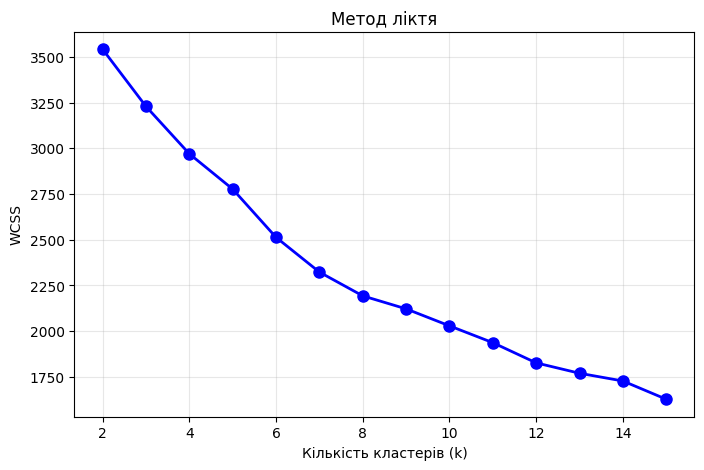

In [4]:
scaler = StandardScaler()
spotify_scaled = scaler.fit_transform(num_spotify)

k_range = range(2, 16)
wcss_values = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(spotify_scaled)
    wcss_values.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(k_range, wcss_values, 'bo-', linewidth=2, markersize=8)
plt.xlabel('Кількість кластерів (k)')
plt.ylabel('WCSS')
plt.title('Метод ліктя')
plt.grid(True, alpha=0.3)
plt.show()

In [5]:
K = 6
kmeans = KMeans(n_clusters=K, random_state=42, n_init=10)
clusters = kmeans.fit_predict(spotify_scaled)

num_spotify.insert(0, 'cluster', clusters)
print("Кількість треків у кластері:")
num_spotify['cluster'].value_counts().sort_index()

Кількість треків у кластері:


cluster
0     56
1    108
2    125
3     66
4      3
5     59
Name: count, dtype: int64

In [6]:
pca = PCA(n_components=3)
pca_data = pca.fit_transform(spotify_scaled)

num_spotify['pca1'] = pca_data[:, 0]
num_spotify['pca2'] = pca_data[:, 1]
num_spotify['pca3'] = pca_data[:, 2]

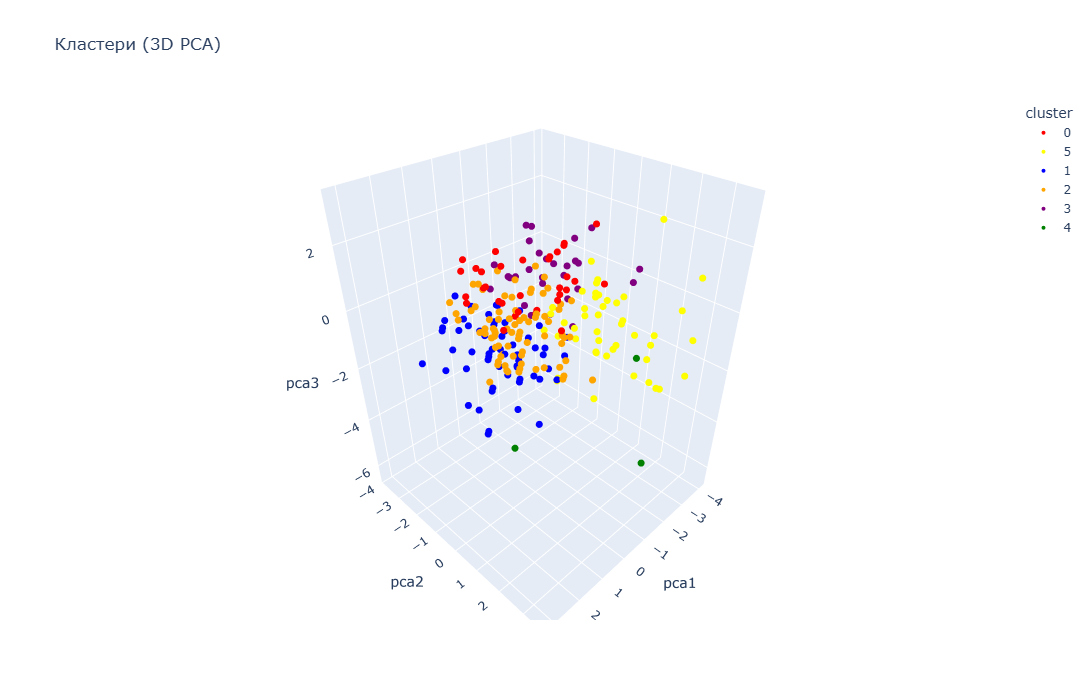

In [7]:
plot_sp = num_spotify.copy()
plot_sp['cluster'] = plot_sp['cluster'].astype(str)

cluster_colors = {
    0: 'red',
    1: 'blue',
    2: 'orange',
    3: 'purple',
    4: 'green',
    5: 'yellow'
}
color_map = {str(k): v for k, v in cluster_colors.items()}

fig = px.scatter_3d(
    plot_sp,
    x='pca1',
    y='pca2',
    z='pca3',
    color='cluster',
    color_discrete_map=color_map,
    title='Кластери (3D PCA)',
    height=700
)

fig.update_traces(marker=dict(size=4))
fig.show()

In [8]:
features_for_analysis = [
    'danceability',
    'energy',
    'loudness',
    'speechiness',
    'acousticness',
    'instrumentalness',
    'liveness',
    'valence',
    'tempo',
    'popularity'
]

cluster_means = num_spotify.groupby('cluster')[features_for_analysis].mean().round(3)
cluster_means

,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,popularity
cluster,,,,,,,,,,
0,0.780,0.653,-5.213,0.104,0.200,0.002,0.118,0.578,113.324,94.661
1,0.680,0.696,-5.545,0.124,0.085,0.001,0.196,0.432,154.179,87.676
2,0.697,0.720,-4.638,0.087,0.193,0.000,0.143,0.555,104.927,86.840
3,0.878,0.489,-8.735,0.242,0.150,0.004,0.219,0.404,112.553,87.409
4,0.633,0.642,-8.461,0.112,0.187,0.198,0.133,0.226,113.727,87.000
5,0.624,0.474,-7.423,0.123,0.553,0.002,0.179,0.393,108.801,88.627


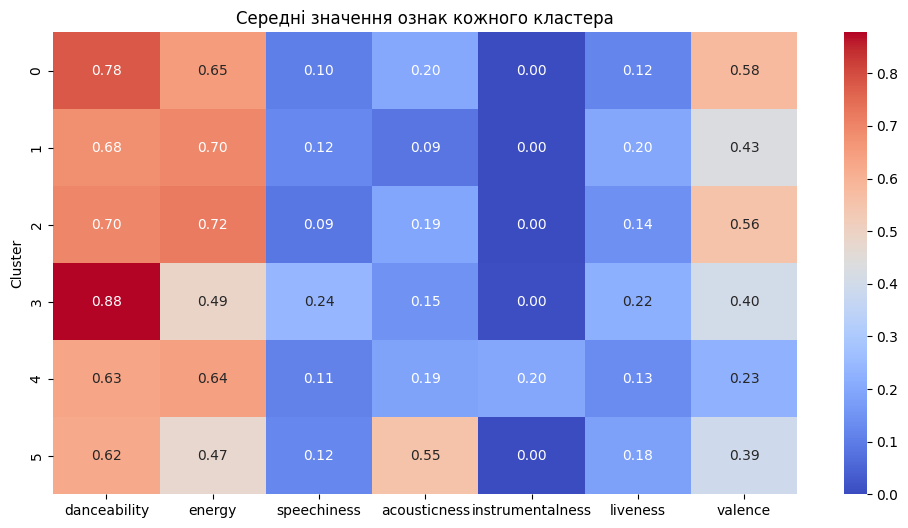

In [10]:
cluster_heatmap = cluster_means.drop(columns=['tempo', 'popularity', 'loudness'])
plt.figure(figsize=(12,6))
sns.heatmap(cluster_heatmap, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Середні значення ознак кожного кластера')
plt.ylabel('Cluster')
plt.show()

Кластер 0 - енергійні танцювальні треки з вокалом з відносно високим емоційним забарвленням

Кластер 1 - досить висока енергійність, середня емоційна забарвленість, танцювальні треки

Кластер 2 - енергійцні треки, підходять для танців, з високим емоційним забарвленням

Кластер 3 - треки, що дуже підходять для танців; велика кількість вокалу, мало енергійності, середнє емоційне забарвлення

Кластер 4 - середня енергійність, танцювальність, висока інструментальність, низьке емоційне забарвлення

Кластер 5 - висока акустичність, низька енергійність, низька енергійність